# Select a TPU slice and provision your Cloud TPU VM

Runnable locally on CPU or on a Cloud TPU VM.

- Choose between a free notebook TPU (Colab/Kaggle) and a single-host Google Cloud TPU VM (`v5litepod-4` or `v6e-4`).
- Provision a Cloud TPU VM using `gcloud compute tpus tpu-vm create` or a Flex-start instance group, then connect over SSH.
- Create an isolated `.venv` on the TPU VM, install `jax[tpu]`, and validate `jax.default_backend()`, `jax.device_count()`, and a synchronized `jax.pmap` computation.
- Delete the Cloud TPU VM and confirm with `gcloud compute tpus tpu-vm list` that zero active TPU nodes remain.

Before you run a Transformer, sharded step, Pallas kernel, or distributed workload on a TPU, you need a working TPU runtime and a repeatable receipt that proves JAX actually discovered TPU chips—and you need a teardown habit so an idle Cloud TPU VM never keeps billing.

## The idea

Getting a TPU running separates into four explicit boundaries: choosing an access route (free Colab/Kaggle TPU vs single-host Google Cloud TPU VM via on-demand or Flex-start), creating the TPU VM in a supported zone, installing `jax[tpu]` inside an isolated `.venv` on the TPU VM host, and recording a machine-checkable runtime receipt before deleting the VM.

## Why a TPU VM is a host computer attached to accelerator chips

When you create a Cloud TPU VM, Google Cloud allocates a Linux host machine directly attached over PCIe/ICI to the TPU chips on that board—for example, a `v5litepod-4` VM is one Linux host attached to $4$ TPU v5e chips (`16` GiB HBM each). Your SSH session lands on that Linux host, not inside a chip.

Because your commands run on the TPU VM's Linux host, standard Linux environment rules still apply: you create a Python virtual environment (`.venv`), install `jax[tpu]` from the libtpu wheel index, and run Python scripts there. When Python imports `jax`, `libtpu` initializes the attached TPU chips and `jax.default_backend()` reports `'tpu'`.

Every Cloud TPU VM bills while it exists (`READY` or `STOPPED`), even if no Python process is running. Therefore, a complete TPU workflow always pairs creation (`tpu-vm create`) and verification with artifact retrieval (`tpu-vm scp`) and verified deletion (`tpu-vm delete` followed by `tpu-vm list`).

$$
N_{\text{chips}} = \text{device\_count}(\texttt{'tpu'}), \qquad \text{HBM}_{\text{total}} = N_{\text{chips}} \times \text{HBM}_{\text{chip}}
$$

### End-to-end Cloud TPU VM lifecycle from create to verified teardown

**Predict:** Where does Python execute when you SSH into a Cloud TPU VM, and when does billing stop?

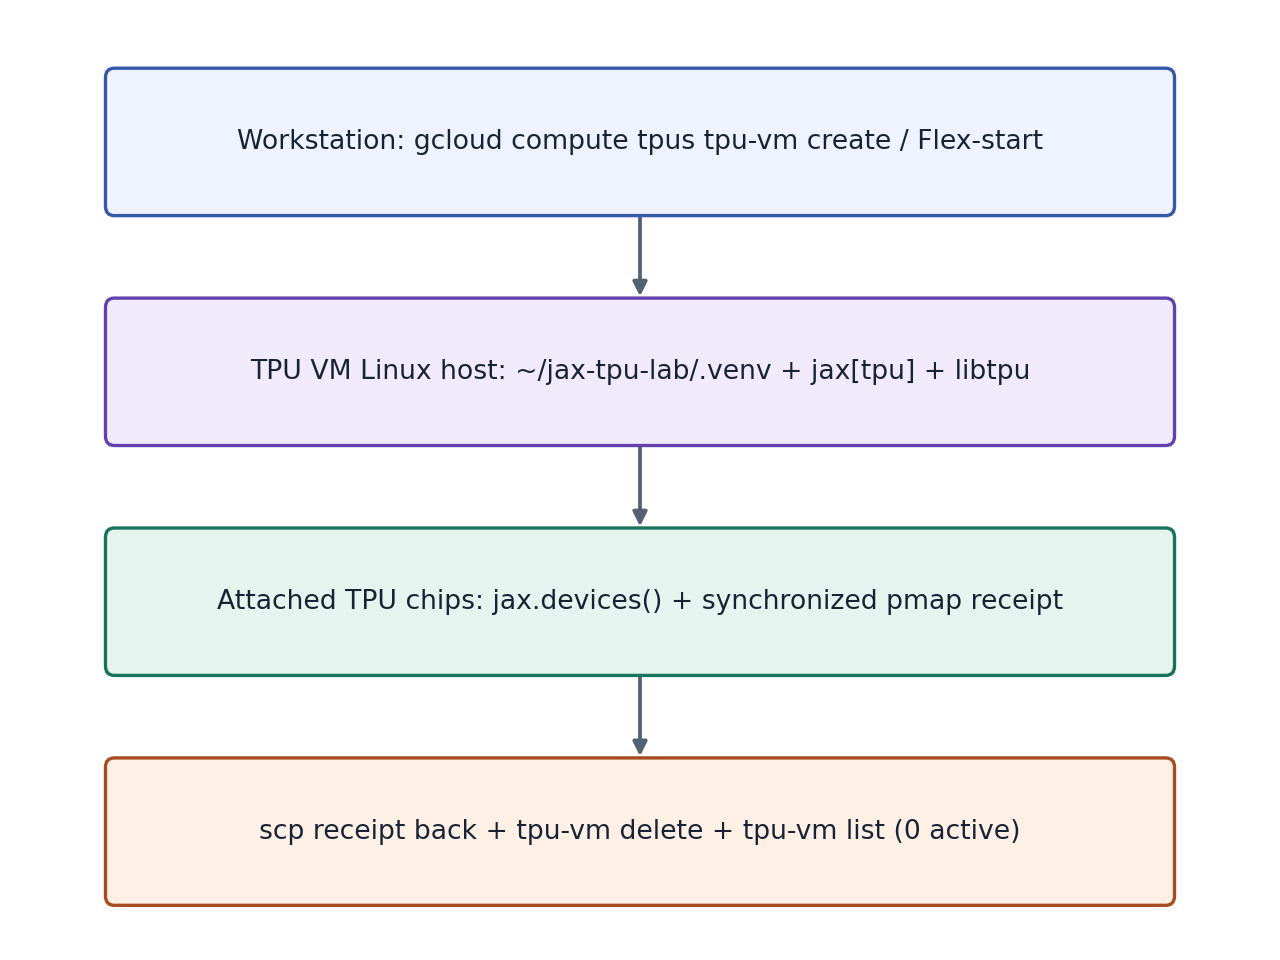

*Architecture and dataflow mechanism diagram.*

Read top to bottom: your workstation runs `gcloud` to allocate the Cloud TPU VM, SSH starts Python inside `~/jax-tpu-lab/.venv` on the TPU VM host, `libtpu` dispatches XLA programs to the attached TPU chips, `scp` retrieves the runtime receipt, and `tpu-vm delete` releases the resource.

### Pause and reason

Why does creating a Cloud TPU VM and seeing `STATUS: READY` in `gcloud` not prove that your JAX experiment can run on TPU?

<details><summary>Compare your reasoning</summary>

`STATUS: READY` only confirms that the Linux VM and attached TPU hardware were allocated. You still must verify inside Python on that VM that `libtpu` loads, `jax.default_backend() == 'tpu'`, `jax.device_count()` matches the topology, and a synchronized computation completes.

</details>

## 1. Choose how to get a TPU: Colab/Kaggle vs Google Cloud TPU VM

You can complete every TPU verification in this course using either a hosted notebook TPU or a Google Cloud TPU VM:

- **Route 1 — Hosted Notebook TPU (Google Colab or Kaggle)**: Fastest zero-CLI start. In Google Colab, open **Runtime → Change runtime type → Hardware accelerator → TPU** (such as TPU v5e-1 or TPU v2-8). Skip `gcloud` provisioning and run the Python runtime-receipt verifier directly inside a notebook cell.
- **Route 2A — Direct Cloud TPU VM (`gcloud compute tpus tpu-vm create`)**: Best when you want direct SSH and `scp` access to a single-host `v5litepod-4` (`4` chips) or `v6e-4` (`4` chips) VM in your own GCP project.
- **Route 2B — Flex-start Queued Provisioning (`gcloud beta compute instance-groups managed create`)**: Recommended when on-demand TPU capacity in a zone is busy or you want a bounded `--max-run-duration` that automatically terminates the instance when the lease expires.

## 2. Authenticate `gcloud`, enable the TPU API, and check quota

On your local workstation (or inside Google Cloud Shell), set your project ID, zone, and TPU name, enable `tpu.googleapis.com`, and inspect the available accelerator types in your chosen zone before requesting hardware. Using a single-host slice such as `v5litepod-4` (`4` chips on `1` host) avoids multi-host coordination while still letting you run real `jax.pmap` and mesh sharding across $4$ TPU devices.

**Configure project, zone, and enable the Cloud TPU API**

```bash
# Configure project, zone, and enable the Cloud TPU API
export PROJECT_ID="your-gcp-project-id"
export ZONE="us-west1-c"
export TPU_NAME="jax-tpu-course"
export ACCELERATOR_TYPE="v5litepod-4"
export RUNTIME_VERSION="v2-alpha-tpuv5-lite"

gcloud auth login
gcloud config set project "$PROJECT_ID"
gcloud services enable tpu.googleapis.com
gcloud compute tpus accelerator-types list --zone="$ZONE"
```

**Expected:** Lists the TPU accelerator types supported in $ZONE, including v5litepod-1, v5litepod-4, and v5litepod-8.

## 3. Create the Cloud TPU VM (Direct or Flex-start) and verify READY state

Run either the direct `tpu-vm create` command (add `--spot` if you are using Spot quota) or the Flex-start template + managed instance group commands below. Wait until `describe` reports `state: READY`.

**Route 2A: Create a single-host Cloud TPU v5e-4 VM directly**

```bash
# Route 2A: Create a single-host Cloud TPU v5e-4 VM directly
gcloud compute tpus tpu-vm create "$TPU_NAME" \
  --zone="$ZONE" \
  --accelerator-type="$ACCELERATOR_TYPE" \
  --version="$RUNTIME_VERSION"

gcloud compute tpus tpu-vm describe "$TPU_NAME" \
  --zone="$ZONE" \
  --format="value(state,acceleratorType,networkEndpoints[0].ipAddress)"
```

**Expected:** Outputs READY, v5litepod-4, and the internal IP address of the newly provisioned TPU VM.

**Route 2B: Alternative Flex-start queued provisioning with automatic 4-hour termination**

```bash
# Route 2B: Alternative Flex-start queued provisioning with automatic 4-hour termination
gcloud beta compute instance-templates create tpu-course-flex-tmpl \
  --machine-type=ct5lp-hightpu-4t \
  --provisioning-model=FLEX_START \
  --max-run-duration=4h \
  --instance-termination-action=DELETE \
  --reservation-affinity=none

gcloud beta compute instance-groups managed create tpu-course-mig \
  --zone="$ZONE" --template=tpu-course-flex-tmpl --size=0

gcloud beta compute instance-groups managed resize-requests create tpu-course-mig \
  --zone="$ZONE" --resize-request=req-tpu-1 --resize-by=1
```

**Expected:** Creates a Flex-start request for a 4-chip TPU v5e instance that automatically deletes after 4 hours.

## 4. SSH into the TPU VM, create `.venv`, and install `jax[tpu]`

Once the TPU VM is `READY`, bootstrap a clean virtual environment on the remote host and install `jax[tpu]` from the official `libtpu` wheel index. Keeping this `.venv` at `~/jax-tpu-lab/.venv` gives every subsequent lesson in the course a known interpreter path.

**Bootstrap ~/jax-tpu-lab/.venv with jax[tpu] on the TPU VM**

```bash
# Bootstrap ~/jax-tpu-lab/.venv with jax[tpu] on the TPU VM
gcloud compute tpus tpu-vm ssh "$TPU_NAME" --zone="$ZONE" --command="
  set -euo pipefail
  mkdir -p ~/jax-tpu-lab
  python3 -m venv ~/jax-tpu-lab/.venv
  source ~/jax-tpu-lab/.venv/bin/activate
  pip install -U pip
  pip install 'jax[tpu]' -f https://storage.googleapis.com/jax-releases/libtpu_releases.html
  pip install flax optax orbax-checkpoint numpy matplotlib
  python -c 'import jax; print(\"BACKEND:\", jax.default_backend(), \"COUNT:\", jax.device_count(), \"DEVICES:\", jax.devices())'
"
```

**Expected:** Prints BACKEND: tpu COUNT: 4 and lists 4 TpuDevice objects (for v5litepod-4).

## 5. Run the runtime contract check and always delete the TPU VM when finished

Before claiming a TPU runtime is ready—or before starting a long run—execute a script that checks both the requested backend/device count and a synchronized computation across all local devices, writes a JSON receipt, copies the receipt back to your laptop, and deletes the TPU VM when your session is finished.

**Copy back any receipts and delete the Cloud TPU VM to stop billing**

```bash
# Copy back any receipts and delete the Cloud TPU VM to stop billing
gcloud compute tpus tpu-vm delete "$TPU_NAME" --zone="$ZONE" --quiet
gcloud compute tpus tpu-vm list --zone="$ZONE"
```

**Expected:** Deletes the TPU VM and confirms Listed 0 items so no idle TPU resource remains.

## Write the runtime contract and synchronized pmap verifier

Create main.py with verify_runtime_contract so the same function validates CPU locally and TPU on your Cloud TPU VM.

In [1]:
# Step 1 — Write the runtime contract and synchronized pmap verifier: The verifier checks both device discovery and a synchronized pmap...
# Import hashlib for this computation.
import hashlib
import json
import os
import platform
import jax
import jax.numpy as jnp
import numpy as np


# Function `verify_runtime_contract(expected_backend, min_devices)` implementing this stage's computation:
def verify_runtime_contract(expected_backend=None, min_devices=1):
    # Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `backend`.
    backend = jax.default_backend()
    # Query the active JAX devices into `devices`.
    devices = jax.devices()
    # Query the active JAX devices into `local_devices`.
    local_devices = jax.local_devices()
    # Compute `target` from `expected_backend or backend`
    target = expected_backend or backend
    # Create evenly spaced index values in `x`.
    x = jnp.arange(len(local_devices) * 8, dtype=jnp.float32).reshape(len(local_devices), 8)
    # Reduce across the target axis to summarize `per_device`.
    per_device = jax.pmap(lambda row: jnp.sum(row * row))(x)
    # Synchronize host execution until asynchronous device computation completes.
    total = float(jax.block_until_ready(jnp.sum(per_device)))
    # Create evenly spaced index values in `expected_total`.
    expected_total = float(np.sum(np.arange(len(local_devices) * 8, dtype=np.float64) ** 2))
    # Evaluate the compound expression for `contract_ok`.
    contract_ok = (
        backend == target
        and len(devices) >= min_devices
        and np.isclose(total, expected_total)
    )
    # Construct dictionary `receipt` with the structured fields for this stage.
    receipt = {
        "python": platform.python_version(),
        "jax": jax.__version__,
        "expected_backend": target,
        "observed_backend": backend,
        "device_count": len(devices),
        "local_device_count": len(local_devices),
        "device_kinds": [str(d.device_kind) for d in devices],
        "pmap_sum_of_squares": total,
        "expected_sum_of_squares": expected_total,
        "contract_ok": bool(contract_ok),
    }
    # Read or serialize artifact data on disk (`receipt['receipt_sha256']`).
    receipt["receipt_sha256"] = hashlib.sha256(
        json.dumps(receipt, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest()[:16]
    # Return `receipt` to the caller.
    return receipt

The verifier checks both device discovery and a synchronized pmap reduction across all local devices, then hashes the receipt.

## Compare single-host TPU slice topologies and emit the receipt

Append the slice topology table and runtime receipt check to main.py.

In [2]:
# Step 2 — Compare single-host TPU slice topologies and emit the receipt: Calculating total chips and HBM per slice makes the hardware...
topologies = [
    {"slice": "v5litepod-1", "hosts": 1, "chips_per_host": 1, "hbm_gib_per_chip": 16},
    {"slice": "v5litepod-4", "hosts": 1, "chips_per_host": 4, "hbm_gib_per_chip": 16},
    {"slice": "v5litepod-8", "hosts": 1, "chips_per_host": 8, "hbm_gib_per_chip": 16},
    {"slice": "v6e-4", "hosts": 1, "chips_per_host": 4, "hbm_gib_per_chip": 32},
]
# Iterate over `spec` to step through the computation:
for spec in topologies:
    # Compute `spec["total_chips"]` from `spec["hosts"] * spec["chips_per_host"]`
    spec["total_chips"] = spec["hosts"] * spec["chips_per_host"]
    # Compute `spec["total_hbm_gib"]` from `spec["total_chips"] * spec["hbm_gib_per_chip"]`
    spec["total_hbm_gib"] = spec["total_chips"] * spec["hbm_gib_per_chip"]

# Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `receipt`.
receipt = verify_runtime_contract(expected_backend=jax.default_backend(), min_devices=1)
# Assert invariant `receipt["contract_ok"] is True` holds
assert receipt["contract_ok"] is True
# Print the observed values to compare against the expected result.
print("Verified runtime receipt:", json.dumps(receipt, sort_keys=True))
# Print diagnostic summary of the computed outputs.
print("Single-host TPU slice HBM totals (GiB):", {t["slice"]: t["total_hbm_gib"] for t in topologies})

Verified runtime receipt: {"contract_ok": true, "device_count": 1, "device_kinds": ["cpu"], "expected_backend": "cpu", "expected_sum_of_squares": 140.0, "jax": "0.9.2", "local_device_count": 1, "observed_backend": "cpu", "pmap_sum_of_squares": 140.0, "python": "3.14.3", "receipt_sha256": "4ddc0cbb323fe3bd"}
Single-host TPU slice HBM totals (GiB): {'v5litepod-1': 16, 'v5litepod-4': 64, 'v5litepod-8': 128, 'v6e-4': 128}


Calculating total chips and HBM per slice makes the hardware capacity concrete before you provision a Cloud TPU VM.

## Step 3: Verify invariants on the completed state

Run the final shape and numerical assertions to confirm the state built in Steps 1 and 2.

In [3]:
receipt = verify_runtime_contract(expected_backend=jax.default_backend(), min_devices=1)
assert receipt["contract_ok"] is True

Checking these invariants confirms the computation is ready for the full worked experiment.

## Run the example

In [4]:
# Step 1 — Write the runtime contract and synchronized pmap verifier: The verifier checks both device discovery and a synchronized pmap...
# Import hashlib for this computation.
import hashlib
import json
import os
import platform
import jax
import jax.numpy as jnp
import numpy as np


# Function `verify_runtime_contract(expected_backend, min_devices)` implementing this stage's computation:
def verify_runtime_contract(expected_backend=None, min_devices=1):
    # Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `backend`.
    backend = jax.default_backend()
    # Query the active JAX devices into `devices`.
    devices = jax.devices()
    # Query the active JAX devices into `local_devices`.
    local_devices = jax.local_devices()
    # Compute `target` from `expected_backend or backend`
    target = expected_backend or backend
    # Create evenly spaced index values in `x`.
    x = jnp.arange(len(local_devices) * 8, dtype=jnp.float32).reshape(len(local_devices), 8)
    # Reduce across the target axis to summarize `per_device`.
    per_device = jax.pmap(lambda row: jnp.sum(row * row))(x)
    # Synchronize host execution until asynchronous device computation completes.
    total = float(jax.block_until_ready(jnp.sum(per_device)))
    # Create evenly spaced index values in `expected_total`.
    expected_total = float(np.sum(np.arange(len(local_devices) * 8, dtype=np.float64) ** 2))
    # Evaluate the compound expression for `contract_ok`.
    contract_ok = (
        backend == target
        and len(devices) >= min_devices
        and np.isclose(total, expected_total)
    )
    # Construct dictionary `receipt` with the structured fields for this stage.
    receipt = {
        "python": platform.python_version(),
        "jax": jax.__version__,
        "expected_backend": target,
        "observed_backend": backend,
        "device_count": len(devices),
        "local_device_count": len(local_devices),
        "device_kinds": [str(d.device_kind) for d in devices],
        "pmap_sum_of_squares": total,
        "expected_sum_of_squares": expected_total,
        "contract_ok": bool(contract_ok),
    }
    # Read or serialize artifact data on disk (`receipt['receipt_sha256']`).
    receipt["receipt_sha256"] = hashlib.sha256(
        json.dumps(receipt, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest()[:16]
    # Return `receipt` to the caller.
    return receipt


# Step 2 — Compare single-host TPU slice topologies and emit the receipt: Calculating total chips and HBM per slice makes the hardware...
topologies = [
    {"slice": "v5litepod-1", "hosts": 1, "chips_per_host": 1, "hbm_gib_per_chip": 16},
    {"slice": "v5litepod-4", "hosts": 1, "chips_per_host": 4, "hbm_gib_per_chip": 16},
    {"slice": "v5litepod-8", "hosts": 1, "chips_per_host": 8, "hbm_gib_per_chip": 16},
    {"slice": "v6e-4", "hosts": 1, "chips_per_host": 4, "hbm_gib_per_chip": 32},
]
# Iterate over `spec` to step through the computation:
for spec in topologies:
    # Compute `spec["total_chips"]` from `spec["hosts"] * spec["chips_per_host"]`
    spec["total_chips"] = spec["hosts"] * spec["chips_per_host"]
    # Compute `spec["total_hbm_gib"]` from `spec["total_chips"] * spec["hbm_gib_per_chip"]`
    spec["total_hbm_gib"] = spec["total_chips"] * spec["hbm_gib_per_chip"]

# Check which hardware backend (`cpu`, `gpu`, or `tpu`) JAX selected for `receipt`.
receipt = verify_runtime_contract(expected_backend=jax.default_backend(), min_devices=1)
# Assert invariant `receipt["contract_ok"] is True` holds
assert receipt["contract_ok"] is True
# Print the observed values to compare against the expected result.
print("Verified runtime receipt:", json.dumps(receipt, sort_keys=True))
# Print diagnostic summary of the computed outputs.
print("Single-host TPU slice HBM totals (GiB):", {t["slice"]: t["total_hbm_gib"] for t in topologies})

Verified runtime receipt: {"contract_ok": true, "device_count": 1, "device_kinds": ["cpu"], "expected_backend": "cpu", "expected_sum_of_squares": 140.0, "jax": "0.9.2", "local_device_count": 1, "observed_backend": "cpu", "pmap_sum_of_squares": 140.0, "python": "3.14.3", "receipt_sha256": "4ddc0cbb323fe3bd"}
Single-host TPU slice HBM totals (GiB): {'v5litepod-1': 16, 'v5litepod-4': 64, 'v5litepod-8': 128, 'v6e-4': 128}


Expected: Prints a JSON runtime receipt with contract_ok: true, observed_backend, device_count, pmap_sum_of_squares: 140.0 (on 1 local device), and the single-host TPU slice HBM totals.

## Single-host Cloud TPU slice chip counts and total HBM capacity

Predict: How does total HBM scale across `v5litepod-1`, `v5litepod-4`, `v5litepod-8`, and `v6e-4` single-host TPU VMs?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Single-host Cloud TPU slice chip counts and total HBM capacity
# Construct dictionary `visual_data` with the structured fields for this stage.
visual_data = {
    'kind': 'bar',
    'labels': [t['slice'] for t in topologies],
    'xlabel': 'single-host Cloud TPU slice',
    'ylabel': 'count / capacity',
    'series': [
        {'label': 'TPU chips on host', 'y': [float(t['total_chips']) for t in topologies]},
        {'label': 'total HBM (GiB)', 'y': [float(t['total_hbm_gib']) for t in topologies]},
    ],
}

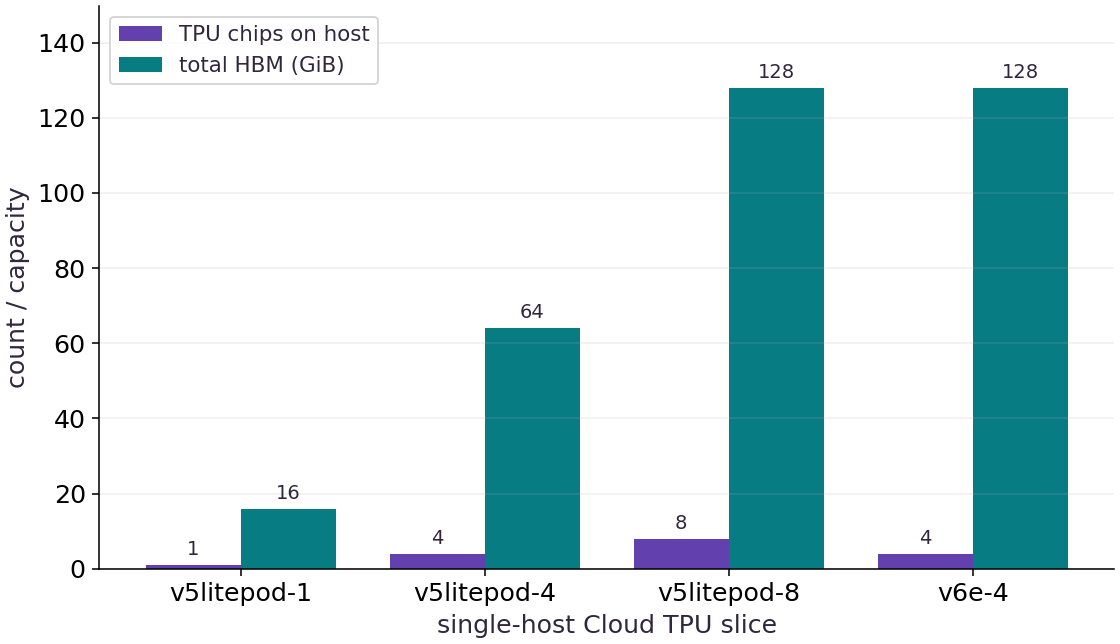

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis lists four single-host Cloud TPU VM slice types. The two bars per slice show the number of attached TPU chips on that single Linux host and the total High Bandwidth Memory (HBM in GiB) across those chips.

### Connect it to the computation

Moving from `v5litepod-1` (`16` GiB) to `v5litepod-4` (`64` GiB) or `v6e-4` (`128` GiB) multiplies HBM capacity while keeping a single VM host, so you can test `jax.pmap` and `NamedSharding` across `4` or `8` chips from one SSH command.

## Reject a mismatched backend or missing TPU devices immediately

Predict: What should verify_runtime_contract return if you require 4 TPU devices on a single-CPU host?

In [7]:
# Experiment — Reject a mismatched backend or missing TPU devices immediately: Failing the contract check explicitly prevents a script from...
mismatch = verify_runtime_contract(expected_backend="tpu", min_devices=4)
# Print the observed values to compare against the expected result.
print("Mismatch contract_ok:", mismatch["contract_ok"], "observed:", mismatch["observed_backend"], "devices:", mismatch["device_count"])
# Assert that `mismatch["contract_ok"] == (jax.default_backend() == "tpu" and jax.device_count() >= 4)`.
assert mismatch["contract_ok"] == (jax.default_backend() == "tpu" and jax.device_count() >= 4)

Mismatch contract_ok: False observed: cpu devices: 1


Expected: On CPU, mismatch['contract_ok'] is False while still recording the observed backend and device count.

Failing the contract check explicitly prevents a script from silently running on CPU when you intended to benchmark or train on a TPU VM.

## Verify single-host vs multi-host process counts

Predict: Why does v5litepod-4 need only one SSH command while v5litepod-16 requires --worker=all?

In [8]:
# Experiment — Verify single-host vs multi-host process counts: Single-host TPU VMs attach all chips to one Linux VM; multi-host...
slice_hosts = {"v5litepod-1": 1, "v5litepod-4": 1, "v5litepod-8": 1, "v5litepod-16": 4}
# Compute `needs_multi_host` from `{k: (v > 1) for k, v in slice_hosts.items()}`
needs_multi_host = {k: (v > 1) for k, v in slice_hosts.items()}
# Print the observed values to compare against the expected result.
print("Requires --worker=all and jax.distributed.initialize():", needs_multi_host)
# Assert that `needs_multi_host["v5litepod-4"] is False and needs_multi_host["v5litepod-16"] is True`.
assert needs_multi_host["v5litepod-4"] is False and needs_multi_host["v5litepod-16"] is True

Requires --worker=all and jax.distributed.initialize(): {'v5litepod-1': False, 'v5litepod-4': False, 'v5litepod-8': False, 'v5litepod-16': True}


Expected: v5litepod-1, v5litepod-4, and v5litepod-8 run on 1 host (False); v5litepod-16 spans 4 hosts (True).

Single-host TPU VMs attach all chips to one Linux VM; multi-host slices attach chips across multiple Linux VMs that must all launch the Python process.

## Your exercise

Call `verify_runtime_contract` for the active backend with `min_devices=1`, then compute how many `v5litepod-4` chips and total GiB of HBM are available on that single-host slice and assert both values.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `verify_runtime_contract(...)` — Call `verify_runtime_contract` with your updated parameters or inputs from this lesson's workspace.
- `jax.default_backend(...)` — Call `jax.default_backend` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Run `next` to compute `v5e4`.
2. Print the observed values to compare against the expected result.
3. Assert that `checked["contract_ok"] is True and v5e4["total_chips"] == 4 and v5e4["total_hbm_gib"] == 64`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Call verify_runtime_contract for the active backend with...
checked = verify_runtime_contract(...)  # TODO: compute checked
# Run `next` to compute `v5e4`.
v5e4 = next(...)  # TODO: compute v5e4
# Print the observed values to compare against the expected result.
print("Checked receipt sha256:", checked["receipt_sha256"], "v5litepod-4 chips:", v5e4["total_chips"], "HBM GiB:", v5e4["total_hbm_gib"])
# Assert that `checked["contract_ok"] is True and v5e4["total_chips"] == 4 and v5e4["total_hbm_gib"] == 64`.
assert checked["contract_ok"] is True  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Call verify_runtime_contract for the active backend with...
# checked = verify_runtime_contract(...)  # TODO: compute checked
# Run `next` to compute `v5e4`.
# v5e4 = next(...)  # TODO: compute v5e4
# Print the observed values to compare against the expected result.
# print("Checked receipt sha256:", checked["receipt_sha256"], "v5litepod-4 chips:", v5e4["total_chips"], "HBM GiB:", v5e4["total_hbm_gib"])
# Assert that `checked["contract_ok"] is True and v5e4["total_chips"] == 4 and v5e4["total_hbm_gib"] == 64`.
# assert checked["contract_ok"] is True  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Call verify_runtime_contract for the active backend with...
checked = verify_runtime_contract(expected_backend=jax.default_backend(), min_devices=1)
# Run `next` to compute `v5e4`.
v5e4 = next(t for t in topologies if t["slice"] == "v5litepod-4")
# Print the observed values to compare against the expected result.
print("Checked receipt sha256:", checked["receipt_sha256"], "v5litepod-4 chips:", v5e4["total_chips"], "HBM GiB:", v5e4["total_hbm_gib"])
# Assert that `checked["contract_ok"] is True and v5e4["total_chips"] == 4 and v5e4["total_hbm_gib"] == 64`.
assert checked["contract_ok"] is True and v5e4["total_chips"] == 4 and v5e4["total_hbm_gib"] == 64

Checked receipt sha256: 4ddc0cbb323fe3bd v5litepod-4 chips: 4 HBM GiB: 64


## Check whether a model state fits on a single-host TPU slice · Foundations

Given a training state requiring $48$ GiB of HBM, determine which slices in `topologies` have at least $48$ GiB of total HBM.

Hint: Filter `topologies` by `t['total_hbm_gib'] >= 48`.

### How to write: Check whether a model state fits on a single-host TPU slice — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `slice(...)` — Call `slice` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Check whether a model state fits on a single-host TPU slice (Foundations): A single v5litepod-1 chip has 16 GiB HBM, whereas...
2. Print the observed values to compare against the expected result.
3. Assert invariant `fitting_slices == ["v5litepod-4"` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Check whether a model state fits on a single-host TPU slice (Foundations): A single v5litepod-1 chip has 16 GiB HBM, whereas...
fitting_slices = ...  # TODO: compute fitting_slices
# Print the observed values to compare against the expected result.
print("Slices fitting 48 GiB:", fitting_slices)
# Assert invariant `fitting_slices == ["v5litepod-4"` holds
assert fitting_slices  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check whether a model state fits on a single-host TPU slice (Foundations): A single v5litepod-1 chip has 16 GiB HBM, whereas...
# fitting_slices = ...  # TODO: compute fitting_slices
# Print the observed values to compare against the expected result.
# print("Slices fitting 48 GiB:", fitting_slices)
# Assert invariant `fitting_slices == ["v5litepod-4"` holds
# assert fitting_slices  # TODO: complete assertion check

## Reference reasoning

A single v5litepod-1 chip has 16 GiB HBM, whereas v5litepod-4 (64 GiB), v5litepod-8 (128 GiB), and v6e-4 (128 GiB) fit a 48 GiB sharded state on a single host.

In [12]:
# Check whether a model state fits on a single-host TPU slice (Foundations): A single v5litepod-1 chip has 16 GiB HBM, whereas...
fitting_slices = [t["slice"] for t in topologies if t["total_hbm_gib"] >= 48]
# Print the observed values to compare against the expected result.
print("Slices fitting 48 GiB:", fitting_slices)
# Assert invariant `fitting_slices == ["v5litepod-4"` holds
assert fitting_slices == ["v5litepod-4", "v5litepod-8", "v6e-4"]

Slices fitting 48 GiB: ['v5litepod-4', 'v5litepod-8', 'v6e-4']


## Verify the pmap sum-of-squares formula for 4 TPU devices · Transfer / diagnosis

Compute the exact sum of squares that `verify_runtime_contract` expects when `len(local_devices) == 4` (`32` elements `0..31`).

Hint: Sum `np.arange(32, dtype=np.float64) ** 2`.

### How to write: Verify the pmap sum-of-squares formula for 4 TPU devices — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `Mesh + PartitionSpec + NamedSharding` — Maps logical tensor axes onto physical device mesh axes for SPMD data, tensor, or pipeline parallelism.

**Step-by-step implementation plan:**
1. Aggregate array values to compute `four_device_expected`.
2. Print the observed values to compare against the expected result.
3. Assert invariant `four_device_expected == 10416.0` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Verify the pmap sum-of-squares formula for 4 TPU devices (Transfer / diagnosis): On a 4-chip TPU VM (v5litepod-4 or v6e-4), x has shape (4,...
# Aggregate array values to compute `four_device_expected`.
four_device_expected = float(...)  # TODO: compute four_device_expected
# Print the observed values to compare against the expected result.
print("Expected 4-device pmap sum of squares:", four_device_expected)
# Assert invariant `four_device_expected == 10416.0` holds
assert four_device_expected  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Verify the pmap sum-of-squares formula for 4 TPU devices (Transfer / diagnosis): On a 4-chip TPU VM (v5litepod-4 or v6e-4), x has shape (4,...
# Aggregate array values to compute `four_device_expected`.
# four_device_expected = float(...)  # TODO: compute four_device_expected
# Print the observed values to compare against the expected result.
# print("Expected 4-device pmap sum of squares:", four_device_expected)
# Assert invariant `four_device_expected == 10416.0` holds
# assert four_device_expected  # TODO: complete assertion check

## Reference reasoning

On a 4-chip TPU VM (`v5litepod-4` or `v6e-4`), `x` has shape `(4, 8)` and the synchronized sum of squares across the 4 chips is `10416.0`.

In [14]:
# Verify the pmap sum-of-squares formula for 4 TPU devices (Transfer / diagnosis): On a 4-chip TPU VM (v5litepod-4 or v6e-4), x has shape (4,...
# Aggregate array values to compute `four_device_expected`.
four_device_expected = float(np.sum(np.arange(4 * 8, dtype=np.float64) ** 2))
# Print the observed values to compare against the expected result.
print("Expected 4-device pmap sum of squares:", four_device_expected)
# Assert invariant `four_device_expected == 10416.0` holds
assert four_device_expected == 10416.0

Expected 4-device pmap sum of squares: 10416.0


## Checkpoint

Which command sequence proves that your Cloud TPU VM is both usable by JAX and no longer billing when you finish?

1. Running `gcloud compute tpus tpu-vm create` and closing your laptop lid when done
2. Running a Python check on the TPU VM that verifies `jax.default_backend() == 'tpu'` and a synchronized computation, copying receipts back, running `gcloud compute tpus tpu-vm delete`, and confirming `list` is empty
3. Checking `pip list` on your local laptop

## Diagnose

If `gcloud compute tpus tpu-vm create` fails with `RESOURCE_EXHAUSTED`, switch zones or use Flex-start (`Route 2B`). If `jax.default_backend()` prints `cpu` on the TPU VM, confirm that `jax[tpu]` was installed from `libtpu_releases.html` inside the active `.venv` and that no other process holds `/dev/accel*` or `/dev/vfio/*`.

## Evidence

Keep the slice HBM capacity table, single-host vs Pod classification, and gcloud create/describe/delete command log.

## Carry forward

- A Cloud TPU VM is a Linux host directly attached to TPU chips; you SSH into the host and run Python inside a `.venv` with `jax[tpu]`.
- Single-host slices (`v5litepod-1`, `v5litepod-4`, `v5litepod-8`, `v6e-4`) let you run 1 to 8 TPU chips from a single SSH command without multi-host coordination.
- Always pair `tpu-vm create` with a saved runtime receipt and `tpu-vm delete` verified by `tpu-vm list`.

## Primary references

- [Google Cloud TPU VM user guide and architecture](https://cloud.google.com/tpu/docs/system-architecture-tpu-vm)
- [Manage TPU VMs with gcloud](https://cloud.google.com/tpu/docs/managing-tpus-tpu-vm)
- [JAX installation for Cloud TPU](https://docs.jax.dev/en/latest/installation.html)